76 image, 1 esp, 6 k, 1 segment

In [16]:
import pandas as pd
import numpy as np
CSV_PATH = f"csvs/ALL_vggnet_triplets_merged.csv"
df = pd.read_csv(CSV_PATH)

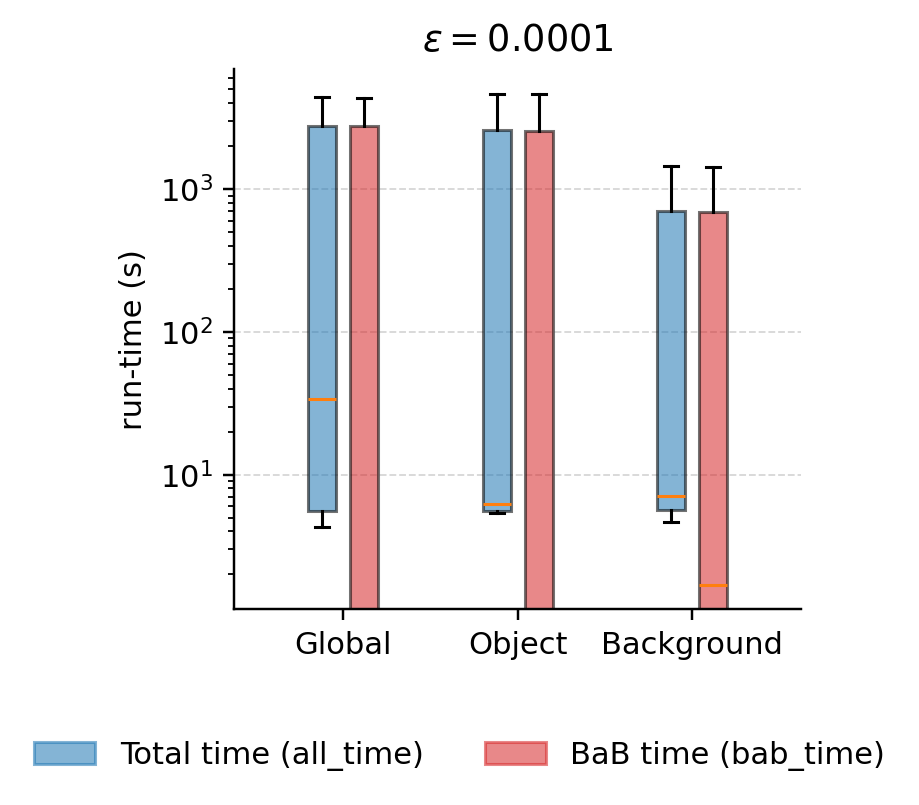

In [17]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------
# Helpers
# ---------------------------
ALL_COL = "all_time"
BAB_COL = "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[ALL_COL] = pd.to_numeric(out[ALL_COL], errors="coerce")
    if BAB_COL in out.columns:
        out[BAB_COL] = pd.to_numeric(out[BAB_COL], errors="coerce")

    out = out.dropna(subset=["eps", "k", ALL_COL]).copy()
    out = out[out[ALL_COL] > 0].copy()

    if BAB_COL in out.columns:
        out[BAB_COL] = out[BAB_COL].fillna(0)
        out.loc[out[BAB_COL] < 0, BAB_COL] = 0

    return out

def paired_boxplot_one_panel(ax, data_pairs, base_labels):
    centers = np.arange(1, len(base_labels) + 1)

    pos_total = centers - 0.12
    pos_bab   = centers + 0.12

    total_data = [p[0] for p in data_pairs]
    bab_data   = [p[1] for p in data_pairs]

    bp1 = ax.boxplot(
        total_data, positions=pos_total, widths=0.16,
        showfliers=False, patch_artist=True
    )
    bp2 = ax.boxplot(
        bab_data, positions=pos_bab, widths=0.16,
        showfliers=False, patch_artist=True
    )

    for b in bp1["boxes"]:
        b.set_facecolor("#1f77b4")
        b.set_alpha(0.55)
    for b in bp2["boxes"]:
        b.set_facecolor("#d62728")
        b.set_alpha(0.55)

    for key in ["whiskers", "caps", "medians"]:
        for line in bp1[key]:
            line.set_linewidth(1.0)
        for line in bp2[key]:
            line.set_linewidth(1.0)

    ax.set_xticks(centers)
    ax.set_xticklabels(base_labels)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

# ---------------------------
# Build subsets
# ---------------------------
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# FIXED k silently
# ---------------------------
FIXED_K = 50176

df_global = df_global[df_global["k"] == FIXED_K]
df_object = df_object[df_object["k"] == FIXED_K]
df_background = df_background[df_background["k"] == FIXED_K]

# ---------------------------
# TWO EPS SIDE BY SIDE
# ---------------------------

eps_vals = [0.0001]

cols = len(eps_vals)
rows = 1

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 3.4, 3.2),
    dpi=220,
    sharey=True,
)

axes = np.array(axes).reshape(1, cols)

base_labels = ["Global", "Object", "Background"]

for j, eps in enumerate(eps_vals):

    ax = axes[0, j]

    g_all = df_global[df_global["eps"] == eps][ALL_COL].values
    g_bab = df_global[df_global["eps"] == eps][BAB_COL].values

    o_all = df_object[df_object["eps"] == eps][ALL_COL].values
    o_bab = df_object[df_object["eps"] == eps][BAB_COL].values

    b_all = df_background[df_background["eps"] == eps][ALL_COL].values
    b_bab = df_background[df_background["eps"] == eps][BAB_COL].values

    paired_boxplot_one_panel(
        ax,
        data_pairs=[(g_all, g_bab), (o_all, o_bab), (b_all, b_bab)],
        base_labels=base_labels
    )

    ax.set_title(rf"$\epsilon={eps:g}$")

    ax.set_yscale("log")

    if j == 0:
        ax.set_ylabel("run-time (s)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ---------------------------
# Title + legend
# ---------------------------

# fig.suptitle(
#    "Verification run-time per ε: total time with embedded BaB time",
#    y=1.05
# )

total_patch = mpatches.Patch(color="#1f77b4", alpha=0.55, label="Total time (all_time)")
bab_patch   = mpatches.Patch(color="#d62728", alpha=0.55, label="BaB time (bab_time)")

fig.legend(
    handles=[total_patch, bab_patch],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.savefig("pdfs/Verification_run-time.pdf", format="pdf", bbox_inches="tight")
plt.show()

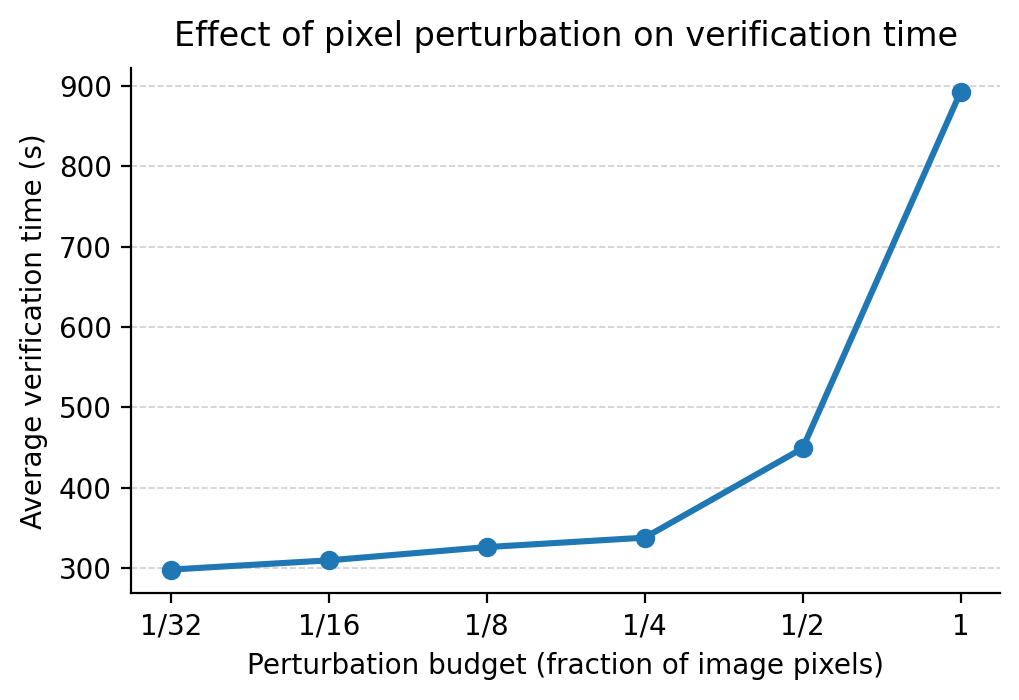

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# numeric safety
# ---------------------------
df["k"] = pd.to_numeric(df["k"], errors="coerce")
df["all_time"] = pd.to_numeric(df["all_time"], errors="coerce")

# ---------------------------
# k values: smallest -> full image
# ---------------------------
pixel_vals = np.array([
    1568,    # 1/32
    3136,    # 1/16
    6272,    # 1/8
    12544,   # 1/4
    25088,   # 1/2
    50176,   # 1
])

# ---------------------------
# Filter + aggregate
# ---------------------------
d = df[df["k"].isin(pixel_vals)].dropna(subset=["all_time"]).copy()

avg_time = (
    d.groupby("k")["all_time"]
     .mean()
     .reindex(pixel_vals)   # keeps this exact order
     .values
)

# ---------------------------
# x-axis labels
# ---------------------------
x_labels = ["1/32", "1/16", "1/8", "1/4", "1/2", "1"]

x_pos = np.arange(len(pixel_vals))

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(5.2, 3.6), dpi=200)

plt.plot(
    x_pos,
    avg_time,
    marker="o",
    linewidth=2.2,
    markersize=6,
)

plt.xticks(x_pos, x_labels)
plt.xlabel("Perturbation budget (fraction of image pixels)")
plt.ylabel("Average verification time (s)")
plt.title("Effect of pixel perturbation on verification time", pad=8)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("pdfs/Average_verification_time.pdf", format="pdf", bbox_inches="tight")
plt.show()

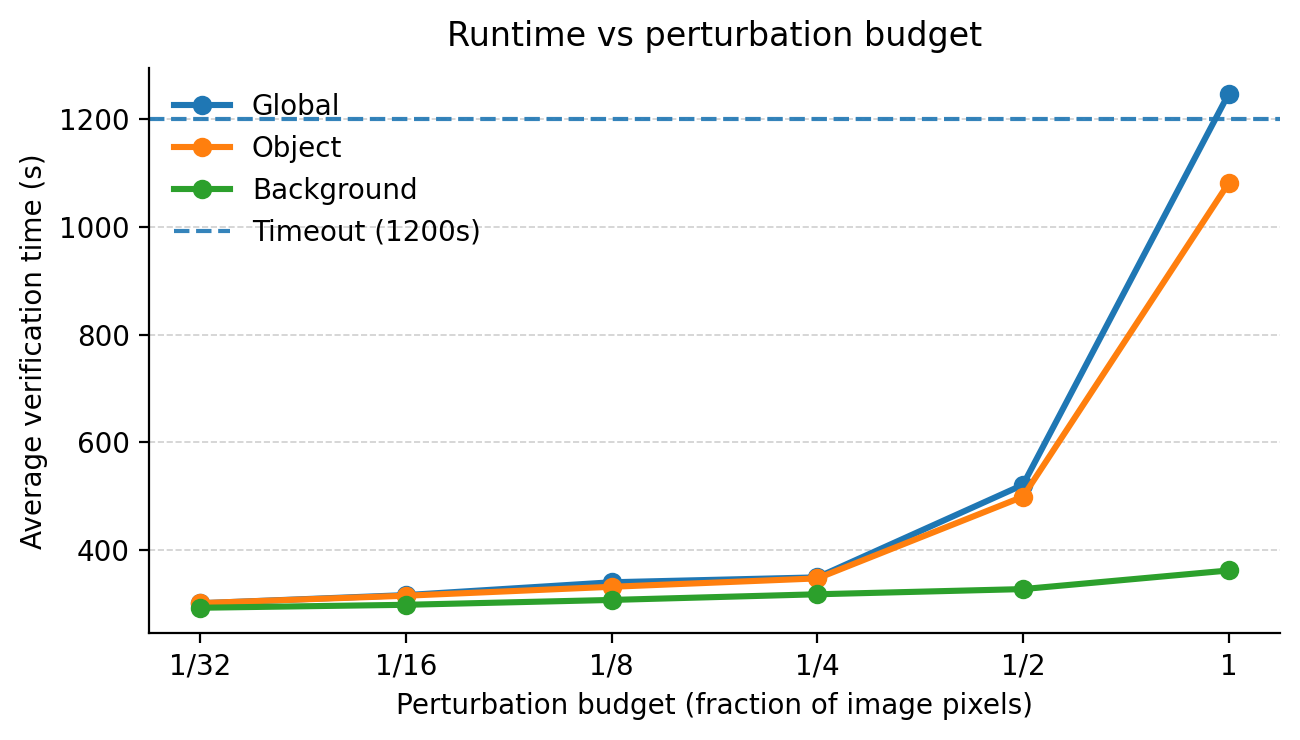

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# numeric safety
# ---------------------------
for c in ["k", "all_time", "eps"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ---------------------------
# k values: smallest -> full
# ---------------------------
pixel_vals = np.array([
    1568,    # 1/32
    3136,    # 1/16
    6272,    # 1/8
    12544,   # 1/4
    25088,   # 1/2
    50176,   # 1
])

x_labels = ["1/32", "1/16", "1/8", "1/4", "1/2", "1"]
x_pos = np.arange(len(pixel_vals))

# ---------------------------
# Filter to Global/Object/Background
# ---------------------------
d = df[df["tag"].isin(["global", "fix_nonmask", "fix_mask"])].copy()
d = d[d["k"].isin(pixel_vals)].dropna(subset=["all_time"])

# Optional: fix one epsilon
# d = d[d["eps"] == 0.0001]

# ---------------------------
# Average time by (tag, k)
# ---------------------------
avg = (
    d.groupby(["tag", "k"])["all_time"]
     .mean()
     .unstack("k")
     .reindex(columns=pixel_vals)
)

avg_glb = (
    avg.loc["global"].values
    if "global" in avg.index
    else np.full(len(pixel_vals), np.nan)
)

avg_obj = (
    avg.loc["fix_nonmask"].values
    if "fix_nonmask" in avg.index
    else np.full(len(pixel_vals), np.nan)
)

avg_bg = (
    avg.loc["fix_mask"].values
    if "fix_mask" in avg.index
    else np.full(len(pixel_vals), np.nan)
)

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(6.6, 3.8), dpi=200)

ax.plot(
    x_pos, avg_glb,
    marker="o", linewidth=2.2, markersize=6,
    label="Global"
)

ax.plot(
    x_pos, avg_obj,
    marker="o", linewidth=2.2, markersize=6,
    label="Object"
)

ax.plot(
    x_pos, avg_bg,
    marker="o", linewidth=2.2, markersize=6,
    label="Background"
)

# Timeout line
TIMEOUT = 1200
ax.axhline(TIMEOUT, linestyle="--", linewidth=1.5, alpha=0.9, label="Timeout (1200s)")

# Axis styling
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Perturbation budget (fraction of image pixels)")
ax.set_ylabel("Average verification time (s)")
ax.set_title("Runtime vs perturbation budget", pad=8)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import os
import re

CSV_PATH = "csvs/ALL_vggnet_triplets_merged.csv"
df = pd.read_csv(CSV_PATH)

# --------------------------------------------------
# Find vnnlib column automatically
# --------------------------------------------------
vnn_col = None
for c in df.columns:
    if df[c].astype(str).str.contains(r"\.vnnlib", case=False, na=False).any():
        vnn_col = c
        break

if vnn_col is None:
    raise RuntimeError("No column with .vnnlib found — print df.columns.")

# --------------------------------------------------
# Infer region from filename
# --------------------------------------------------
def infer_region(v):
    s = str(v).lower()
    if "global" in s:
        return "global"
    if "fixmask" in s or "fix_mask" in s:
        return "object"
    if "fixnonmask" in s or "fix_nonmask" in s:
        return "background"
    return "unknown"

df["region"] = df[vnn_col].map(infer_region)

# --------------------------------------------------
# Infer image id if missing
# --------------------------------------------------
if "image" not in df.columns:
    def infer_image(v):
        base = os.path.basename(str(v))
        base = re.sub(r"\.vnnlib$", "", base, flags=re.I)
        return base.split("_")[0]

    df["image"] = df[vnn_col].map(infer_image)

# --------------------------------------------------
# Filter k=50176 and normalize result
# --------------------------------------------------
df = df[df["k"] == 50176].copy()

df["result"] = df["result"].astype(str).str.strip().str.lower()

# UNSAT = anything starting with "unsat"
is_unsat = df["result"].str.startswith("unsat")

df["is_unsat"] = is_unsat

# --------------------------------------------------
# Pivot per image/region (now boolean)
# --------------------------------------------------
pivot = (
    df[df["region"].isin(["global", "object", "background"])]
    .pivot_table(
        index="image",
        columns="region",
        values="is_unsat",
        aggfunc="all"   # if duplicates exist → all must be unsat
    )
)

# --------------------------------------------------
# Keep rows where GLOBAL is UNSAT
# --------------------------------------------------
subset = pivot[pivot["global"] == True]

print(f"{len(subset)} images have GLOBAL UNSAT at k=50176\n")

print(subset[["object", "background"]].sort_index())

# Optional save:
# subset.reset_index().to_csv("global_unsat_obj_bg_results_k50176.csv", index=False)

3 images have GLOBAL UNSAT at k=50176

region                  object  background
image                                     
n01560419_bulbul          True        True
n01644373_tree_frog       True        True
n01817953_African_grey    True        True


In [25]:
import pandas as pd
import os, re

CSV_PATH = "csvs/ALL_vggnet_triplets_merged.csv"
df = pd.read_csv(CSV_PATH)
df = df[df["k"] == 50176].copy()

# -----------------------------
# Find vnnlib column automatically
# -----------------------------
vnn_col = None
for c in df.columns:
    if df[c].astype(str).str.contains(r"\.vnnlib", case=False, na=False).any():
        vnn_col = c
        break
if vnn_col is None:
    raise RuntimeError("No column containing .vnnlib found. Print df.columns and pick the right one.")

# -----------------------------
# Infer region from filename
# -----------------------------
def infer_region(v):
    s = str(v).lower()
    if "global" in s:
        return "global"
    if "fixmask" in s or "fix_mask" in s:
        return "object"
    if "fixnonmask" in s or "fix_nonmask" in s:
        return "background"
    return "unknown"

df["region"] = df[vnn_col].map(infer_region)

# -----------------------------
# Infer image id if missing
# -----------------------------
if "image" not in df.columns:
    def infer_image(v):
        base = os.path.basename(str(v))
        base = re.sub(r"\.vnnlib$", "", base, flags=re.I)
        return base.split("_")[0]
    df["image"] = df[vnn_col].map(infer_image)

# -----------------------------
# Filter k=50176 and normalize result
# -----------------------------
df = df[df["k"] == 50176].copy()
df["result"] = df["result"].astype(str).str.strip()

# UNSAT = anything starting with "unsat"
is_unsat = df["result"].str.startswith("unsat")

df["is_unsat"] = is_unsat

# -----------------------------
# Pivot to see all regions per image
# (does NOT require global/background to exist)
# -----------------------------
pivot = (
    df[df["region"].isin(["global", "object", "background"])]
    .pivot_table(
        index="image",
        columns="region",
        values="result",
        aggfunc=lambda x: ",".join(sorted(set(x)))  # handle duplicates safely
    )
)

# -----------------------------
# Keep images where OBJECT is UNSAT
# (global/background can be anything or missing)
# -----------------------------
subset = pivot[pivot["object"] == UNSAT].copy()

print(f"{len(subset)} images have OBJECT UNSAT at k=50176\n")

# Show global/background too if present (can be NaN if missing)
cols_to_show = [c for c in ["global", "object", "background"] if c in subset.columns]
print(subset[cols_to_show].sort_index())

# Optional: save
# subset.reset_index()[["image"] + cols_to_show].to_csv("object_unsat_k50176.csv", index=False)

34 images have OBJECT UNSAT at k=50176

region                               global       object     background
image                                                                  
n01443537_goldfish            timeout False  unsat False    unsat False
n01491361_tiger_shark         timeout False  unsat False  timeout False
n01496331_electric_ray        timeout False  unsat False  timeout False
n01532829_house_finch                 error  unsat False  timeout False
n01534433_junco               timeout False  unsat False    unsat False
n01537544_indigo_bunting      timeout False  unsat False  timeout False
n01560419_bulbul                unsat False  unsat False    unsat False
n01582220_magpie              timeout False  unsat False  timeout False
n01592084_chickadee                   error  unsat False  timeout False
n01644373_tree_frog             unsat False  unsat False    unsat False
n01644900_tailed_frog         timeout False  unsat False    unsat False
n01665541_leatherback_tu